# 02 · Pricing the imbalance hedge
### From a directional signal to an execution decision

Notebook 01 builds a day-ahead entry signal and holds it to imbalance settlement.
That earns the DA–cashout spread, while leaving the position exposed to the final
settlement price. Here the trading question is **how much of that exposure is
worth closing intraday?**

We compare **0%, 25%, 50%, 75% and 100% intraday closure** on identical entries.
The two endpoints are controls; the intermediate policies price the trade-off.
The sequence is: **payoff → risk → hedge cost → market regimes → stress day**.

## The experiment

| Decision | Specification |
|:--|:--|
| Entry | Notebook 01's saved selected-run signals; no retraining or new signal selection |
| Size | **1 MWh per admitted half-hour signal** (equivalent to 2 MW for that period) |
| Exit | Close fraction $h$ at the period's MID proxy; settle the remaining $1-h$ at SSP for longs / SBP for shorts |
| Costs | £1 per entry MWh, plus £2 per MWh closed intraday; identical assumptions for every hedge |
| Comparison | Same timestamps, direction, quantity and complete-price mask for all five policies; TP/SL off |
| Scope | All saved 2018 forecast dates; development and retrospective evaluation also reported separately |

The headline curve is **cumulative net research PnL at fixed volume**. It does
not compound capital or simulate a funded account, so an account loss limit
does not terminate this payoff experiment. Capital sizing, collateral and account
survival are separate implementation questions: see the
[book-risk study](../../docs/EXECUTION_RISK_STUDY.md) and
[start-date appendix](11_start_date_sensitivity.ipynb).

MID is an aggregate traded-price index, not an executable quote or an intraday
price path. This tests a proxy hedge, not executable order timing. The common-price mask is an ex-post coverage filter, not a tradable entry rule.
The saved prices are revised historical observations, not a point-in-time archive. The
last 60 forecast dates were inspected in earlier research: they are retrospective
evaluation, not a fresh validation sample. The five static policies are displayed
without selecting a production winner.

In [1]:
%matplotlib inline
from pathlib import Path
import hashlib
import json
import sys

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter
import numpy as np
import pandas as pd
from IPython.display import display, Markdown

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'pyproject.toml').exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from src.evaluation.hedging import fixed_volume_hedges, summarise_hedges

RUNS = ROOT / 'artifacts/da_positioning'
RUN = json.loads((RUNS / 'best_run.json').read_text())['best_run']
ARTIFACTS = RUNS / RUN
INPUTS = {
    'features': ARTIFACTS / 'features/features.parquet',
    'signals': ARTIFACTS / 'virtual/trading/signals.csv',
    'predictions': ARTIFACTS / 'virtual/trading/predictions.csv',
}
HEDGES = (0.0, 0.25, 0.5, 0.75, 1.0)
Q, FEE, CROSSING = 1.0, 1.0, 2.0
COLORS = {0.: '#185c9a', .25: '#008f87', .5: '#d39321', .75: '#8765a4', 1.: '#c85c60'}
LABELS = {0.: 'Hold to imbalance', .25: '25% intraday', .5: '50% intraday',
          .75: '75% intraday', 1.: 'Full intraday exit'}
INK, MUTED, GRID = '#192d42', '#62758a', '#e3eaf0'
plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': '#fbfcfe',
    'axes.edgecolor': GRID, 'axes.labelcolor': INK, 'text.color': INK,
    'xtick.color': MUTED, 'ytick.color': MUTED, 'font.family': 'DejaVu Sans',
    'font.size': 10, 'axes.titlesize': 12, 'axes.titleweight': 'bold',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': GRID, 'grid.alpha': .75,
    'axes.axisbelow': True, 'figure.dpi': 120, 'savefig.dpi': 160,
})
cash = FuncFormatter(lambda value, _: f'{value:,.0f}')

def polish(ax, ylabel=None):
    ax.grid(axis='x', visible=False)
    ax.yaxis.set_major_formatter(cash)
    if ylabel:
        ax.set_ylabel(ylabel)

def desk_table(frame, formats=None):
    return (frame.style.format(formats or {}, na_rep='—')
        .set_table_styles([
            {'selector': 'th', 'props': [('background-color', '#edf3f8'), ('color', INK),
                                        ('text-align', 'left'), ('padding', '9px')]},
            {'selector': 'td', 'props': [('padding', '8px 12px'), ('text-align', 'right')]},
            {'selector': 'caption', 'props': [('text-align', 'left'), ('padding', '8px')]},
        ]))

No event loop hook running.


In [2]:
features = pd.read_parquet(INPUTS['features'])
signals = pd.read_csv(INPUTS['signals'])
predictions = pd.read_csv(INPUTS['predictions'])
features['time'] = pd.to_datetime(features['time'], utc=True)
signals['time'] = pd.to_datetime(signals['delivery_time'], utc=True)
predictions['time'] = pd.to_datetime(predictions['time'], utc=True)
assert predictions['split'].isin(['development', 'holdout']).all()
assert set(predictions.time) == set(signals.time), 'Signal / forecast timestamps differ'
price_cols = ['day_ahead_price', 'system_sell_price', 'system_buy_price', 'mid_price']
frame = (predictions[['time', 'split']]
    .merge(signals[['time', 'signal', 'predicted_spread']], on='time', validate='one_to_one')
    .merge(features[['time', *price_cols]], on='time', how='left', validate='one_to_one')
    .sort_values('time'))
ledger, daily = fixed_volume_hedges(frame, HEDGES, Q, FEE, CROSSING)
summary = summarise_hedges(daily)
assert ledger.groupby('market_date')['split'].nunique().max() == 1
date_split = ledger.groupby('market_date')['split'].first()
volume = ledger.groupby('market_date')['entry_mwh'].sum()
excluded = ~ledger.eligible & ledger.signal.ne(0)
calendar = pd.date_range(daily.index.min(), daily.index.max(), freq='D')
no_forecasts = calendar.difference(daily.index)
unpriced = daily.index[daily.isna().all(axis=1)]
eval_start = date_split.index[date_split.eq('holdout')].min()
coverage = []
for split, label in [('development', 'Development'), ('holdout', 'Retrospective evaluation')]:
    rows = ledger.split.eq(split)
    dates = date_split.index[date_split.eq(split)]
    coverage.append({'Sample': label, 'Forecast dates': len(dates),
        'Priced dates': int(daily.loc[dates].notna().all(axis=1).sum()),
        'Matched signals': int(ledger.loc[rows, 'entry_mwh'].sum() / Q),
        'Excluded signals': int((excluded & rows).sum())})
coverage = pd.DataFrame(coverage).set_index('Sample')
display(desk_table(coverage))
display(Markdown(
    f"**Coverage:** {len(daily)} saved forecast dates, {int(summary.loc[0, 'priced_days'])} "
    f"dates with common prices, **{int(volume.sum() / Q):,} matched signals**. "
    f"{int(excluded.sum())} signalled periods lack at least one required price and are "
    "excluded from every policy. Partial days are matched-observation subtotals. "
    "No saved forecasts: **21 October–1 November**. No common prices on saved "
    "forecast rows: **9–10 November**. These gaps are marked on the chart and "
    "excluded from daily-risk denominators; they are not fabricated zero-return days."
))

,Forecast dates,Priced dates,Matched signals,Excluded signals
Sample,,,,
Development,90,90,1126,4
Retrospective evaluation,60,58,785,39


<IPython.core.display.Markdown object>

## 1 · The same signal, five exit policies

For signed direction $s\in\{-1,+1\}$ and entry quantity $q$, define the cashout
price $P_C$ as SSP for a long or SBP for a short. The realised payoff is

$$\Pi_h=q\left[(1-h)s(P_C-P_{DA})+hs(P_{MID}-P_{DA})-f-hc\right].$$

Here $f$ is the entry fee and $c$ the intraday crossing assumption. Every curve
uses the same $q$ and entry sample. Changing $h$ changes the exit mix alone.
Blank coverage intervals carry the last accumulated PnL visually; no trades or
risk observations are added there. Drawdown is from the daily cumulative PnL
high-water mark, including the initial zero.

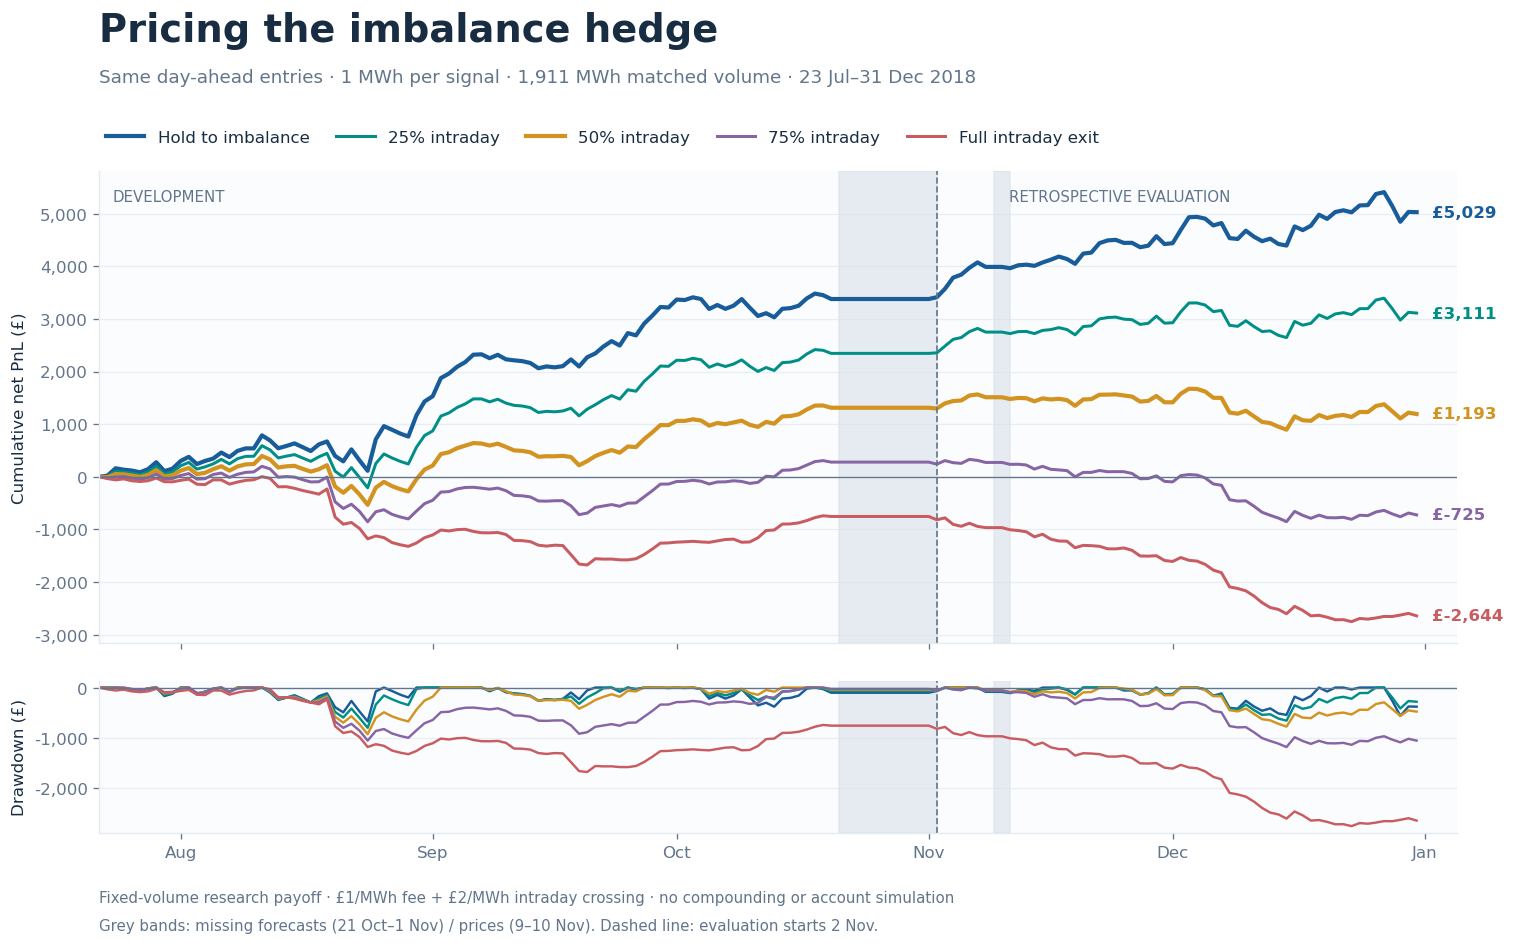

In [3]:
cumulative = daily.cumsum().reindex(calendar).ffill().fillna(0)
drawdown = cumulative - cumulative.cummax().clip(lower=0)
plot_dates = calendar.tz_localize(None)
initial_date = plot_dates[0] - pd.Timedelta(days=1)

fig, (ax, dd_ax) = plt.subplots(2, 1, figsize=(13.8, 8.0), sharex=True,
                               gridspec_kw={'height_ratios': [3.1, 1], 'hspace': .12})
fig.subplots_adjust(left=.08, right=.90, top=.82, bottom=.13)
fig.text(.08, .955, 'Pricing the imbalance hedge', fontsize=23, weight='bold')
fig.text(.08, .912, f'Same day-ahead entries · 1 MWh per signal · {int(volume.sum()):,} MWh matched volume · 23 Jul–31 Dec 2018',
         color=MUTED, fontsize=11)
for h in HEDGES:
    y = np.r_[0, cumulative[h].to_numpy()]
    x = plot_dates.insert(0, initial_date)
    ax.plot(x, y, color=COLORS[h], lw=2.5 if h in (0, .5) else 1.8, label=LABELS[h])
    ax.annotate(f'£{y[-1]:,.0f}', (plot_dates[-1], y[-1]), xytext=(9, 0),
                textcoords='offset points', va='center', color=COLORS[h], weight='bold', fontsize=10)
    dd_ax.plot(x, np.r_[0, drawdown[h].to_numpy()], color=COLORS[h], lw=1.45)
for a in (ax, dd_ax):
    a.axhline(0, color=MUTED, lw=.8)
    a.axvspan(pd.Timestamp('2018-10-21'), pd.Timestamp('2018-11-02'), color='#dce3ea', alpha=.65)
    a.axvspan(pd.Timestamp('2018-11-09'), pd.Timestamp('2018-11-11'), color='#dce3ea', alpha=.65)
    a.axvline(eval_start.tz_localize(None), color=MUTED, ls='--', lw=1)
    polish(a)
ax.set_ylabel('Cumulative net PnL (£)')
dd_ax.set_ylabel('Drawdown (£)')
ax.text(.01, .96, 'DEVELOPMENT', transform=ax.transAxes, color=MUTED, fontsize=9, va='top')
ax.text(.67, .96, 'RETROSPECTIVE EVALUATION', transform=ax.transAxes, color=MUTED, fontsize=9, va='top')
fig.legend(*ax.get_legend_handles_labels(), loc='upper left', bbox_to_anchor=(.075, .878),
           ncol=5, frameon=False, columnspacing=1.6, handlelength=2.3, fontsize=10)
dd_ax.xaxis.set_major_locator(mdates.MonthLocator())
dd_ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
dd_ax.set_xlim(initial_date, plot_dates[-1] + pd.Timedelta(days=5))
fig.text(.08, .058, 'Fixed-volume research payoff · £1/MWh fee + £2/MWh intraday crossing · no compounding or account simulation',
         color=MUTED, fontsize=9)
fig.text(.08, .029, 'Grey bands: missing forecasts (21 Oct–1 Nov) / prices (9–10 Nov). Dashed line: evaluation starts 2 Nov.',
         color=MUTED, fontsize=9)
ASSET = ROOT / 'research/notebooks/assets/equity_curve.png'
ASSET.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(ASSET, dpi=160, facecolor='white')  # The ONLY image exported by this notebook.
plt.show()

In [4]:
tear = summary[['net_pnl', 'daily_volatility', 'worst_day', 'tail_mean_5pct', 'max_drawdown']].copy()
tear.insert(1, 'net_per_mwh', summary.net_pnl / volume.sum())
tear['cashout_mwh'] = (1 - tear.index) * volume.sum()
tear.index = [LABELS[h] for h in tear.index]
tear.columns = ['Net PnL (£)', 'Net £/entry MWh', 'Daily σ (£)', 'Worst day (£)',
                'Worst 5% avg (£)', 'Max DD (£)', 'Cashout MWh']
display(desk_table(tear, {c: '{:,.2f}' if c == 'Net £/entry MWh' else '{:,.0f}' for c in tear.columns})
        .set_caption('Full-period desk summary · fixed entry volume · negative tail / drawdown values are losses'))
display(Markdown(
    f"Daily risk uses **{int(summary.loc[0, 'priced_days'])} priced forecast dates**; "
    f"the tail mean averages the worst **{int(summary.loc[0, 'tail_days'])}** of those dates. "
    "These are cash-PnL statistics. A funded-account return or Sharpe would require a separate "
    "capital, collateral and sizing specification."
))

,Net PnL (£),Net £/entry MWh,Daily σ (£),Worst day (£),Worst 5% avg (£),Max DD (£),Cashout MWh
Hold to imbalance,"5,029",2.63,136,-302,-236,-674,"1,911"
25% intraday,"3,111",1.63,114,-341,-215,-801,"1,433"
50% intraday,"1,193",0.62,95,-406,-203,-928,956
75% intraday,-725,-0.38,82,-470,-206,"-1,184",478
Full intraday exit,"-2,644",-1.38,79,-535,-222,"-2,757",0


<IPython.core.display.Markdown object>

## 2 · Less exposure is not the same as less risk on every measure

After a successful intraday closure, a 50% hedge leaves half the original MWh
exposed to an additional cashout-price shock. That is a mechanical exposure
reduction. Whether it also improves realised daily volatility, tail loss or
drawdown depends on what the intraday exit locks in.

The left panel prices the volatility trade-off. The two loss measures on the
right distinguish **typical bad days** from the **single worst day**. Connecting
the five fixed policies shows sensitivity, not an optimised hedge recommendation.

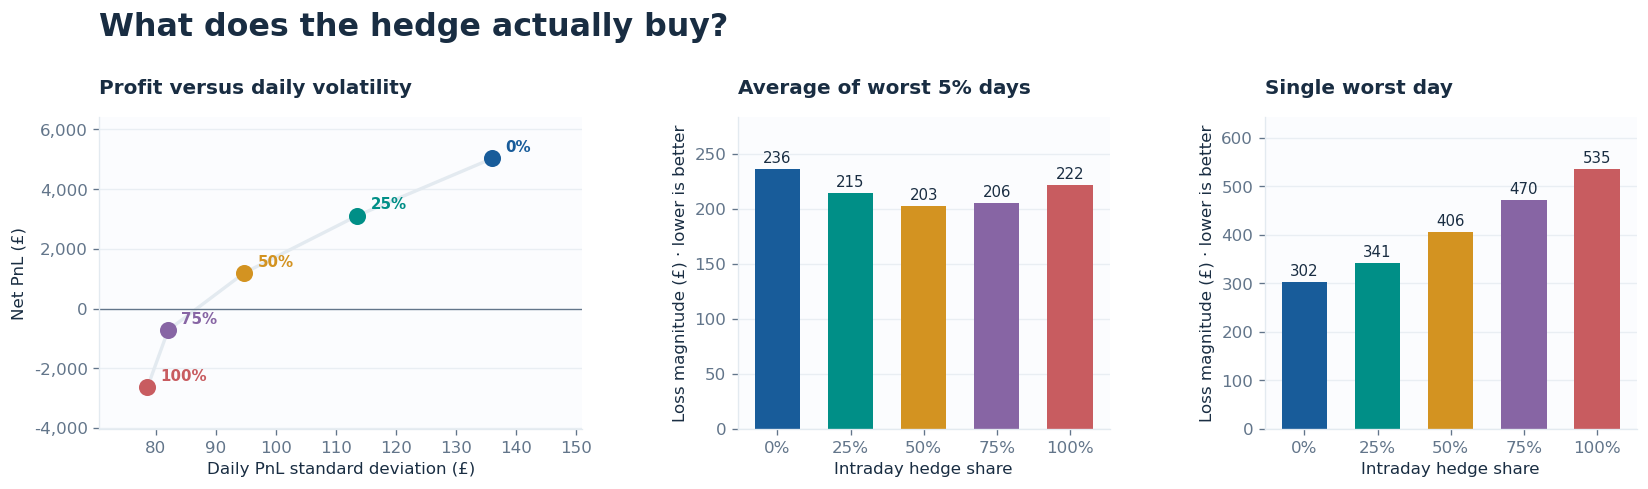

<IPython.core.display.Markdown object>

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.4), gridspec_kw={'width_ratios': [1.3, 1, 1]})
fig.subplots_adjust(left=.065, right=.98, top=.78, bottom=.19, wspace=.38)
fig.suptitle('What does the hedge actually buy?', x=.065, ha='left', fontsize=19, weight='bold')
ax = axes[0]
ax.plot(summary.daily_volatility, summary.net_pnl, color=GRID, lw=2)
for h, row in summary.iterrows():
    ax.scatter(row.daily_volatility, row.net_pnl, color=COLORS[h], s=85, zorder=3)
    ax.annotate(f'{h:.0%}', (row.daily_volatility, row.net_pnl), xytext=(8, 4),
                textcoords='offset points', color=COLORS[h], weight='bold', fontsize=9)
ax.set_title('Profit versus daily volatility', loc='left', pad=14)
ax.set_xlabel('Daily PnL standard deviation (£)')
ax.set_xlim(summary.daily_volatility.min() - 8, summary.daily_volatility.max() + 15)
ax.margins(y=.18)
ax.axhline(0, color=MUTED, lw=.8)
polish(ax, 'Net PnL (£)')
for ax, field, title in [(axes[1], 'tail_mean_5pct', 'Average of worst 5% days'),
                          (axes[2], 'worst_day', 'Single worst day')]:
    values = -summary[field]
    ax.bar(range(5), values, color=[COLORS[h] for h in HEDGES], width=.62)
    for i, v in enumerate(values):
        ax.text(i, v + values.max() * .025, f'{v:,.0f}', ha='center', color=INK, fontsize=9)
    ax.set_xticks(range(5), [f'{h:.0%}' for h in HEDGES])
    ax.set_xlabel('Intraday hedge share')
    ax.set_title(title, loc='left', pad=14)
    ax.set_ylim(0, values.max() * 1.2)
    polish(ax, 'Loss magnitude (£) · lower is better')
plt.show()
base, half = summary.loc[0], summary.loc[.5]
display(Markdown(
    f"**50% hedge:** residual cashout volume halves; daily volatility falls "
    f"**{1-half.daily_volatility/base.daily_volatility:.1%}** and the worst-5% average "
    f"loss falls **{1-abs(half.tail_mean_5pct/base.tail_mean_5pct):.1%}**. "
    f"It retains **{half.net_pnl/base.net_pnl:.1%}** of baseline net profit, while the "
    f"worst-day loss rises **{abs(half.worst_day/base.worst_day)-1:.1%}**. "
    "The hedge reduces one source of risk at a substantial realised cost; it does not dominate the baseline."
))

## 3 · Where the hedge cost comes from

For any hedge fraction, the difference from holding the entire position is

$$\Pi_h-\Pi_0=hq\,s(P_{MID}-P_C)-hq\,c.$$

The first term is the realised exit-price effect; it can be positive or negative.
The second is the extra crossing cost. Entry fees cancel in the comparison.
With fixed quantities and fixed prices, net PnL is linear in $h$: an interior
profit-maximising static hedge cannot emerge from this experiment. An interior
choice would need an explicit risk constraint or preference.

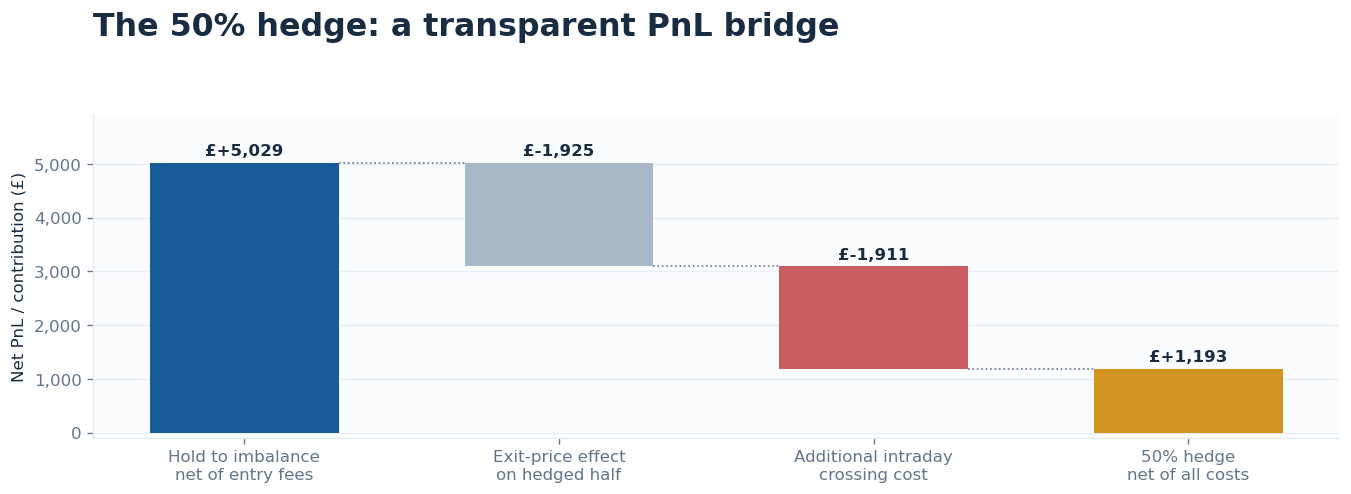

<IPython.core.display.Markdown object>

In [6]:
h = .5
price_effect = h * (ledger.intraday_gross - ledger.imbalance_gross).sum()
crossing_effect = -h * volume.sum() * CROSSING
bridge = [base.net_pnl, price_effect, crossing_effect, half.net_pnl]
assert np.isclose(sum(bridge[:3]), bridge[3])
fig, ax = plt.subplots(figsize=(11.8, 4.5))
fig.subplots_adjust(left=.09, right=.97, top=.79, bottom=.19)
fig.suptitle('The 50% hedge: a transparent PnL bridge', x=.09, ha='left', fontsize=19, weight='bold')
bottoms = [0, bridge[0] + min(bridge[1], 0), sum(bridge[:2]) + min(bridge[2], 0), 0]
heights = [bridge[0], abs(bridge[1]), abs(bridge[2]), bridge[3]]
colors = [COLORS[0], '#a9b8c6', COLORS[1], COLORS[.5]]
ax.bar(range(4), heights, bottom=bottoms, color=colors, width=.6)
levels = [bridge[0], sum(bridge[:2]), sum(bridge[:3])]
for i, level in enumerate(levels):
    ax.plot([i + .3, i + .7], [level, level], color=MUTED, lw=1, ls=':')
for i, value in enumerate(bridge):
    ax.text(i, bottoms[i] + heights[i] + 130, f'£{value:+,.0f}', ha='center', weight='bold')
ax.set_xticks(range(4), ['Hold to imbalance\nnet of entry fees', 'Exit-price effect\non hedged half',
                         'Additional intraday\ncrossing cost', '50% hedge\nnet of all costs'])
ax.set_ylim(min(0, min(bottoms)) - 100, max(base.net_pnl, half.net_pnl) * 1.18)
polish(ax, 'Net PnL / contribution (£)')
plt.show()
display(Markdown(
    f"At the 50% share, exit-price substitution contributes **£{price_effect:+,.0f}** "
    f"and crossing contributes **£{crossing_effect:+,.0f}** relative to cashout. "
    "The cost is therefore not just a fee problem: the intraday price replaces part of the "
    "spread the entry signal was built to capture."
))

## 4 · Does the trade-off travel across the sample?

Monthly net **£ per entry MWh** controls for different trade counts. July and
October are partial forecast months; November also has missing common prices.
The split table below uses the same five policies without retuning. This is
descriptive stability analysis of previously inspected data.

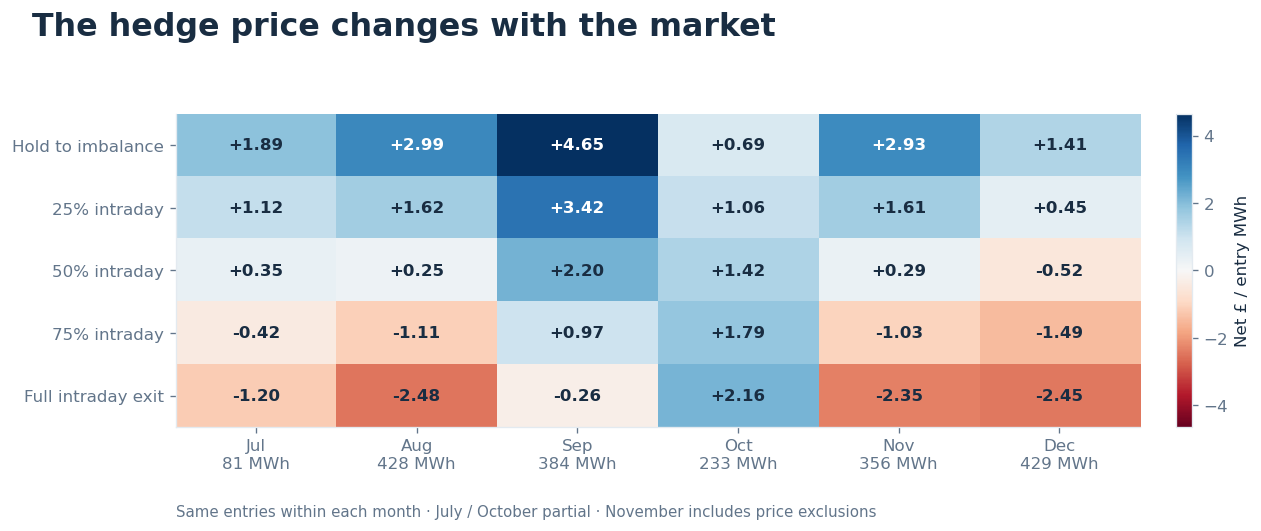

<IPython.core.display.Markdown object>

In [7]:
month = ledger.market_date.dt.strftime('%Y-%m')
monthly_volume = ledger.groupby(month).entry_mwh.sum()
monthly = pd.DataFrame({h: ledger.groupby(month)[f'pnl_{h:g}'].sum() / monthly_volume for h in HEDGES})
values = monthly.T.to_numpy()
limit = np.abs(values).max()
fig, ax = plt.subplots(figsize=(12, 4.5))
fig.subplots_adjust(left=.18, right=.90, top=.79, bottom=.21)
fig.suptitle('The hedge price changes with the market', x=.08, ha='left', fontsize=19, weight='bold')
im = ax.imshow(values, cmap='RdBu', vmin=-limit, vmax=limit, aspect='auto')
ax.grid(False)
ax.set_yticks(range(5), [LABELS[h] for h in HEDGES])
ax.set_xticks(range(len(monthly)), [f'{pd.Timestamp(m).strftime("%b")}\n{monthly_volume.loc[m]:,.0f} MWh'
                                   for m in monthly.index])
for i in range(5):
    for j in range(len(monthly)):
        ax.text(j, i, f'{values[i,j]:+.2f}', ha='center', va='center', weight='bold',
                color='white' if abs(values[i,j]) > .55*limit else INK)
fig.colorbar(im, ax=ax, fraction=.035, pad=.035).set_label('Net £ / entry MWh')
fig.text(.18, .045, 'Same entries within each month · July / October partial · November includes price exclusions',
         color=MUTED, fontsize=9)
plt.show()

split_rows = []
for split, label in [('development', 'Development'), ('holdout', 'Retrospective evaluation')]:
    dates = date_split.index[date_split.eq(split)]
    stats = summarise_hedges(daily.loc[dates])
    for h, row in stats.iterrows():
        split_rows.append({'Sample': label, 'Intraday share': f'{h:.0%}',
            'Net £/MWh': row.net_pnl / volume.loc[dates].sum(),
            'Daily σ (£)': row.daily_volatility, 'Worst 5% avg (£)': row.tail_mean_5pct})
split_table = pd.DataFrame(split_rows).set_index(['Sample', 'Intraday share'])
display(desk_table(split_table, {'Net £/MWh': '{:+.2f}', 'Daily σ (£)': '{:,.0f}',
                                  'Worst 5% avg (£)': '{:,.0f}'}))
display(Markdown(
    "October favours more intraday closure, whereas the other displayed months favour "
    "the cashout endpoint. The 50% hedge is positive on development but negative on "
    "retrospective evaluation. A fixed hedge therefore buys exposure reduction without "
    "demonstrating a stable improvement in net returns."
))

## 5 · A stress day explains the apparent contradiction

**20 August stays in the study.** It is the worst day for the 50% hedge in this
sample, chosen here to explain its loss—not removed from the performance window.
The cached-source review found no missing or duplicate prices on this day and
positive MID trade volume ([audit details](../../docs/EXECUTION_RISK_STUDY.md#audit-of-the-20-august-loss-day)).
Its intraday price spike is not, by itself, evidence of a data error.

The upper panel shows prices by **delivery period**, not a tradable intraday
timeline. The lower panel shows the resulting fixed-volume PnL on signalled
periods. For a short, buying back at a high MID locks in a loss; waiting for a
lower cashout can earn a gain. A hedge removes the remaining uncertainty, but
can crystallise a loss that would otherwise reverse.

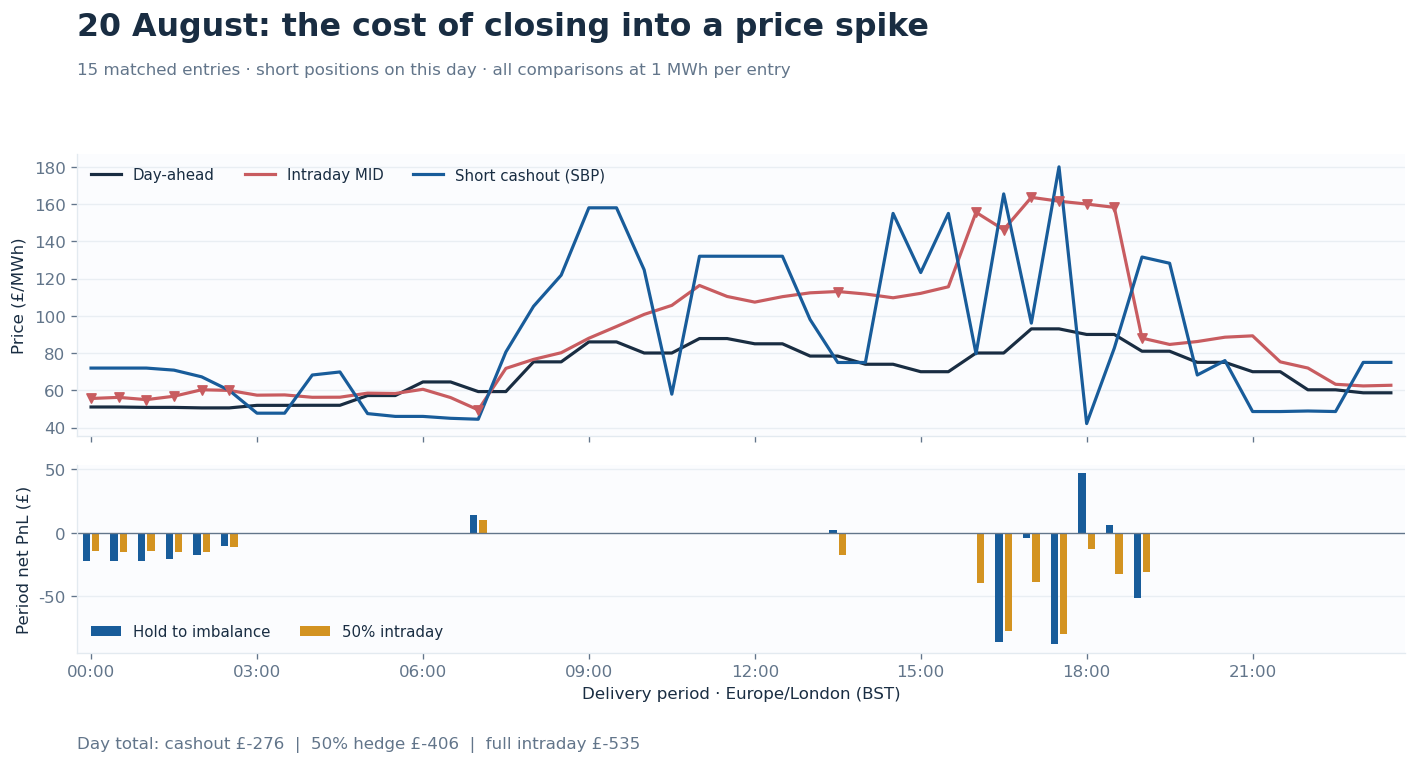

<IPython.core.display.Markdown object>

In [8]:
stress_date = daily[.5].idxmin()
assert str(stress_date.date()) == '2018-08-20', 'Revisit the stress-day narrative for changed inputs'
event = ledger.loc[ledger.market_date.eq(stress_date)].copy()
event['delivery_local'] = event.time.dt.tz_convert('Europe/London').dt.tz_localize(None)
event_prices = features.loc[features.time.dt.tz_convert('Europe/London').dt.normalize().eq(stress_date)].copy()
event_prices['delivery_local'] = event_prices.time.dt.tz_convert('Europe/London').dt.tz_localize(None)
trades = event.loc[event.entry_mwh.gt(0)]
fig, (ax, pnl_ax) = plt.subplots(2, 1, figsize=(12.5, 6.6), sharex=True,
                                gridspec_kw={'height_ratios': [1.5, 1], 'hspace': .12})
fig.subplots_adjust(left=.085, right=.97, top=.79, bottom=.16)
fig.text(.085, .94, '20 August: the cost of closing into a price spike', fontsize=19, weight='bold')
fig.text(.085, .891, f'{len(trades)} matched entries · short positions on this day · all comparisons at 1 MWh per entry',
         color=MUTED, fontsize=10)
for col, name, color in [('day_ahead_price', 'Day-ahead', INK), ('mid_price', 'Intraday MID', COLORS[1]),
                          ('system_buy_price', 'Short cashout (SBP)', COLORS[0])]:
    ax.plot(event_prices.delivery_local, event_prices[col], label=name, color=color, lw=1.9)
ax.scatter(trades.delivery_local, trades.mid_price, marker='v', s=30, color=COLORS[1], zorder=4)
ax.legend(loc='upper left', ncol=3, frameon=False, fontsize=9)
polish(ax, 'Price (£/MWh)')
width = 8 / (24*60)
offset = pd.Timedelta(minutes=5)
pnl_ax.bar(trades.delivery_local - offset, trades['pnl_0'], width=width, color=COLORS[0], label='Hold to imbalance')
pnl_ax.bar(trades.delivery_local + offset, trades['pnl_0.5'], width=width, color=COLORS[.5], label='50% intraday')
pnl_ax.axhline(0, color=MUTED, lw=.8)
pnl_ax.legend(loc='lower left', frameon=False, ncol=2, fontsize=9)
pnl_ax.set_xlabel('Delivery period · Europe/London (BST)')
pnl_ax.xaxis.set_major_locator(mdates.HourLocator(byhour=range(0, 24, 3)))
pnl_ax.set_xlim(stress_date.tz_localize(None) - pd.Timedelta(minutes=15),
                stress_date.tz_localize(None) + pd.Timedelta(hours=23, minutes=45))
pnl_ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
polish(pnl_ax, 'Period net PnL (£)')
fig.text(.085, .04, f'Day total: cashout £{daily.loc[stress_date, 0]:,.0f}  |  50% hedge £{daily.loc[stress_date, .5]:,.0f}  |  full intraday £{daily.loc[stress_date, 1]:,.0f}',
         color=MUTED, fontsize=10)
plt.show()
example = event.loc[event.time.eq(pd.Timestamp('2018-08-20 17:00', tz='UTC'))].iloc[0]
display(Markdown(
    f"At **18:00 BST**, the short enters at DA **£{example.day_ahead_price:.2f}/MWh**. "
    f"MID is **£{example.mid_price:.2f}**, while SBP is **£{example.system_buy_price:.2f}**. "
    f"Net of the stated costs, that 1 MWh earns **£{example['pnl_0']:+.2f}** at cashout "
    f"versus **£{example['pnl_1']:+.2f}** at a full intraday exit. "
    "A 50% closure blends those outcomes. The arithmetic explains why lower residual "
    "exposure can coexist with a larger realised loss."
))

## Trading conclusion

The DA signal and its exit rule are separate research decisions. In this sample,
holding to imbalance earns the most net PnL. Partial closure reduces cashout
exposure and daily volatility, and a 50% closure improves the average tail day;
the profit cost is substantial and the worst single day becomes worse.

**The next strategy hypothesis is selective hedging.** Close more only when
information available before the order indicates that the remaining expected
cashout edge no longer compensates for its uncertainty and execution cost. That
requires an updating forecast of cashout relative to an executable intraday
price, with a cost-aware decision threshold and a residual-exposure limit.

Before claiming that improvement: obtain timestamped prices and forecasts,
freeze the rule and risk budget on development, compare against these static
controls at matched exposure, and score genuinely unseen data. Month labels,
realised cashout and the stress-day outcome cannot be decision inputs. These
data establish the hedge's realised price and risk trade-off; they do not select
or validate that future adaptive strategy.

**Reproduction and presentation.** Re-run this notebook after regenerating
notebook 01's selected-run artifacts. Figures stay inline; only the overview is
exported as `assets/equity_curve.png` for the root README. The final cell writes
a small provenance/metrics JSON, and `scripts/refresh_research_summary.py` refreshes
only the README's compact research caption. The funded-account engine is unchanged.

In [9]:
# Guard the accounting identities and record the exact inputs behind the README figure.
for h in HEDGES:
    np.testing.assert_allclose(ledger[f'pnl_{h:g}'],
        (1-h)*ledger['pnl_0'] + h*ledger['pnl_1'], atol=1e-10)
assert daily.notna().all(axis=1).equals(daily[0].notna())
report = {
    'schema_version': 1, 'run': RUN, 'study': 'fixed_volume_partial_hedges',
    'quantity_mwh_per_signal': Q, 'fee_per_entry_mwh': FEE,
    'crossing_per_intraday_mwh': CROSSING, 'tp_sl': False, 'account_simulation': False,
    'start': str(calendar[0].date()), 'end': str(calendar[-1].date()),
    'forecast_dates': len(daily), 'priced_dates': int(summary.loc[0, 'priced_days']),
    'matched_signals': int(volume.sum() / Q), 'excluded_signals': int(excluded.sum()),
    'no_forecast_dates': [str(d.date()) for d in no_forecasts],
    'unpriced_forecast_dates': [str(d.date()) for d in unpriced],
    'summary': summary.reset_index().to_dict(orient='records'),
    'coverage': coverage.reset_index().to_dict(orient='records'),
    'input_sha256': {str(path.relative_to(ROOT)): hashlib.sha256(path.read_bytes()).hexdigest()
                     for path in INPUTS.values()},
    'image': str(ASSET.relative_to(ROOT)),
    'image_sha256': hashlib.sha256(ASSET.read_bytes()).hexdigest(),
}
REPORT_PATH = ARTIFACTS / 'virtual/trading/partial_hedge_report.json'
REPORT_PATH.write_text(json.dumps(report, indent=2, allow_nan=False) + '\n')
print(f'Accounting checks passed · {len(HEDGES)} policies · {int(volume.sum() / Q):,} matched entries')
print(f'Only exported image: {ASSET.relative_to(ROOT)}')

Accounting checks passed · 5 policies · 1,911 matched entries
Only exported image: research/notebooks/assets/equity_curve.png
